KNN MSE: 0.0469372222222222
KNN R2 Score: 0.7567502825873775
SVM MSE: 0.021268213724863465
SVM R2 Score: 0.8897785865139046


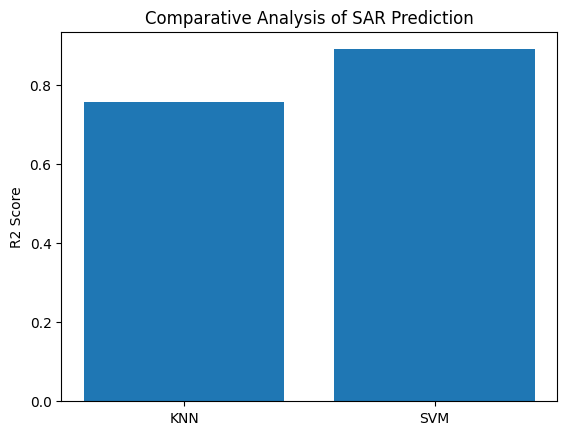

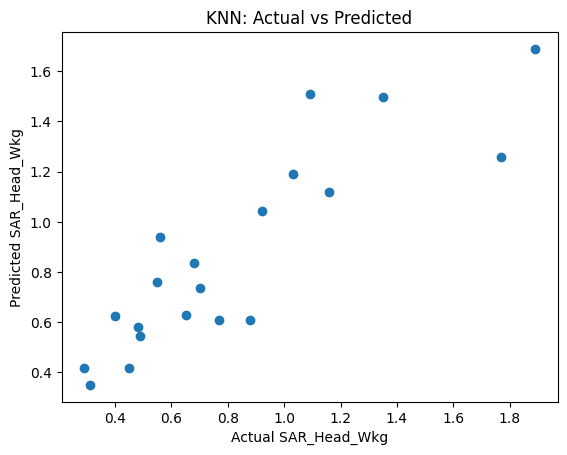

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# --------------------------------------------------
# 1. Load Dataset
# --------------------------------------------------
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/SAR_dataset_100_records (1).csv")

# Encode Brand column
le = LabelEncoder()
data["Device_Brand"] = le.fit_transform(data["Device_Brand"])

# --------------------------------------------------
# 2. Define Features & Target
# --------------------------------------------------
X = data.drop(["SAR_Head_Wkg", "Risk_Level"], axis=1)
y = data["SAR_Head_Wkg"]

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --------------------------------------------------
# 3. KNN Model
# --------------------------------------------------
knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

knn_mse = mean_squared_error(y_test, y_pred_knn)
knn_r2 = r2_score(y_test, y_pred_knn)

# --------------------------------------------------
# 4. SVM Model
# --------------------------------------------------
svm = SVR(kernel="rbf")
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

svm_mse = mean_squared_error(y_test, y_pred_svm)
svm_r2 = r2_score(y_test, y_pred_svm)

# --------------------------------------------------
# 5. Print Results
# --------------------------------------------------
print("KNN MSE:", knn_mse)
print("KNN R2 Score:", knn_r2)

print("SVM MSE:", svm_mse)
print("SVM R2 Score:", svm_r2)

# --------------------------------------------------
# 6. Comparison Graph
# --------------------------------------------------
models = ["KNN", "SVM"]
r2_scores = [knn_r2, svm_r2]

plt.figure()
plt.bar(models, r2_scores)
plt.title("Comparative Analysis of SAR Prediction")
plt.ylabel("R2 Score")
plt.show()


plt.figure()
plt.scatter(y_test, y_pred_knn)
plt.xlabel("Actual SAR_Head_Wkg")
plt.ylabel("Predicted SAR_Head_Wkg")
plt.title("KNN: Actual vs Predicted")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

KNN MSE: 0.0469372222222222
KNN R2 Score: 0.7567502825873775
SVM MSE: 0.021268213724863465
SVM R2 Score: 0.8897785865139046


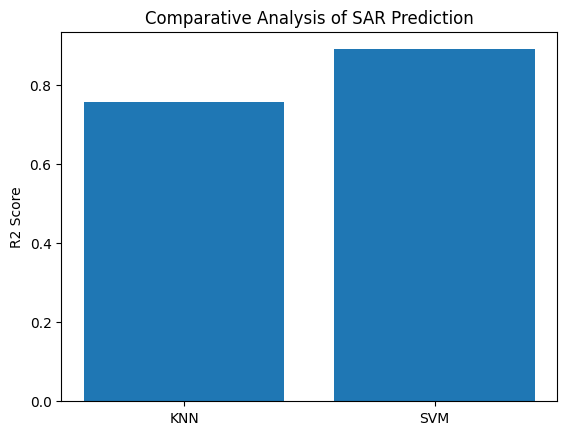


Device Most Affected (Head SAR):
Xiaomi -> 2.0

Device Most Affected (Body SAR):
OnePlus -> 1.99


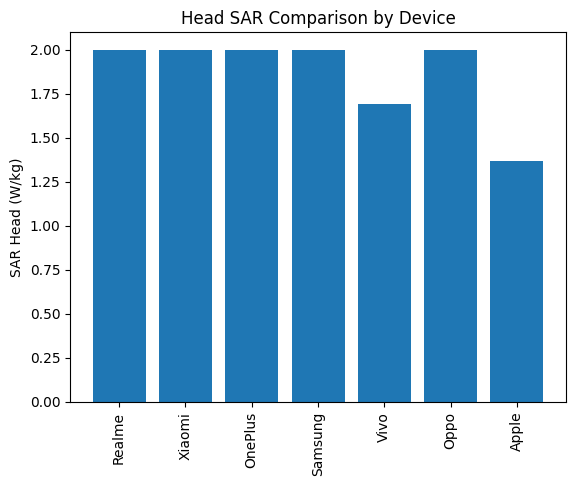

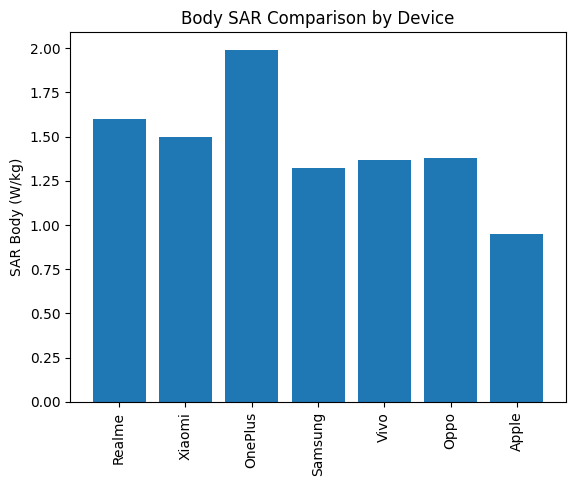

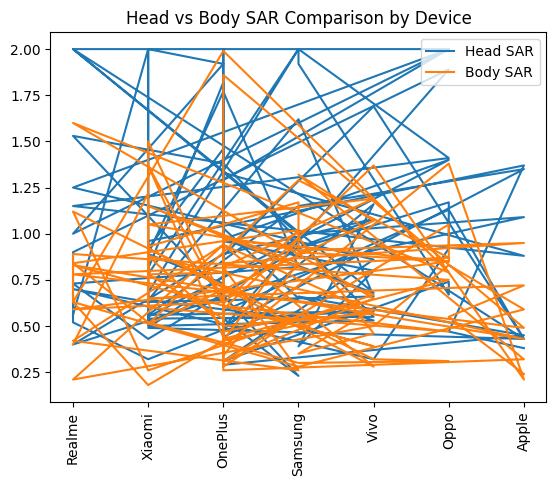

<Figure size 640x480 with 0 Axes>

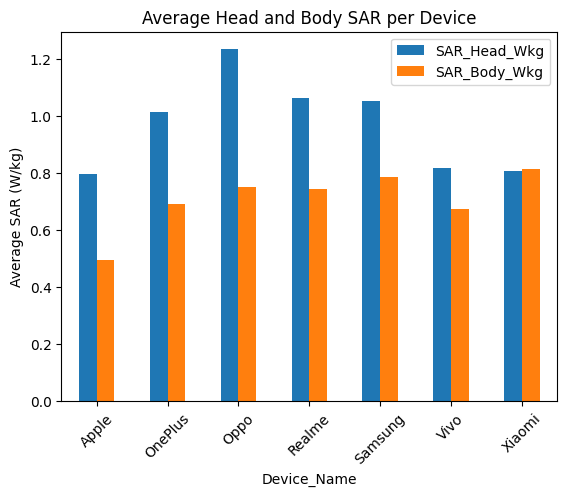

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# --------------------------------------------------
# 1. Load Dataset
# --------------------------------------------------
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/SAR_dataset_100_records (1).csv")

# Encode Brand column
le = LabelEncoder()
data["Device_Brand"] = le.fit_transform(data["Device_Brand"])

# --------------------------------------------------
# 2. Define Features & Target
# --------------------------------------------------
X = data.drop(["SAR_Head_Wkg", "Risk_Level"], axis=1)
y = data["SAR_Head_Wkg"]

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --------------------------------------------------
# 3. KNN Model
# --------------------------------------------------
knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

knn_mse = mean_squared_error(y_test, y_pred_knn)
knn_r2 = r2_score(y_test, y_pred_knn)

# --------------------------------------------------
# 4. SVM Model
# --------------------------------------------------
svm = SVR(kernel="rbf")
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

svm_mse = mean_squared_error(y_test, y_pred_svm)
svm_r2 = r2_score(y_test, y_pred_svm)

# --------------------------------------------------
# 5. Print Model Results
# --------------------------------------------------
print("KNN MSE:", knn_mse)
print("KNN R2 Score:", knn_r2)

print("SVM MSE:", svm_mse)
print("SVM R2 Score:", svm_r2)

# --------------------------------------------------
# 6. Model Comparison Graph (R2 Score)
# --------------------------------------------------
models = ["KNN", "SVM"]
r2_scores = [knn_r2, svm_r2]

plt.figure()
plt.bar(models, r2_scores)
plt.title("Comparative Analysis of SAR Prediction")
plt.ylabel("R2 Score")
plt.show()

# --------------------------------------------------
# 7. Decode Brand Names for Analysis
# --------------------------------------------------
data["Device_Name"] = le.inverse_transform(data["Device_Brand"])

# --------------------------------------------------
# 8. Device Most Affected (Head & Body)
# --------------------------------------------------
max_head = data.loc[data["SAR_Head_Wkg"].idxmax()]
max_body = data.loc[data["SAR_Body_Wkg"].idxmax()]

print("\nDevice Most Affected (Head SAR):")
print(max_head["Device_Name"], "->", max_head["SAR_Head_Wkg"])

print("\nDevice Most Affected (Body SAR):")
print(max_body["Device_Name"], "->", max_body["SAR_Body_Wkg"])

# --------------------------------------------------
# 9. Head SAR Comparison by Device
# --------------------------------------------------
plt.figure()
plt.bar(data["Device_Name"], data["SAR_Head_Wkg"])
plt.xticks(rotation=90)
plt.title("Head SAR Comparison by Device")
plt.ylabel("SAR Head (W/kg)")
plt.show()

# --------------------------------------------------
# 10. Body SAR Comparison by Device
# --------------------------------------------------
plt.figure()
plt.bar(data["Device_Name"], data["SAR_Body_Wkg"])
plt.xticks(rotation=90)
plt.title("Body SAR Comparison by Device")
plt.ylabel("SAR Body (W/kg)")
plt.show()

# --------------------------------------------------
# 11. Combined Head vs Body Graph
# --------------------------------------------------
plt.figure()
plt.plot(data["Device_Name"], data["SAR_Head_Wkg"], label="Head SAR")
plt.plot(data["Device_Name"], data["SAR_Body_Wkg"], label="Body SAR")
plt.xticks(rotation=90)
plt.legend()
plt.title("Head vs Body SAR Comparison by Device")
plt.show()

# --------------------------------------------------
# 12. Average SAR per Device (Professional Analysis)
# --------------------------------------------------
avg_sar = data.groupby("Device_Name")[["SAR_Head_Wkg", "SAR_Body_Wkg"]].mean()

plt.figure()
avg_sar.plot(kind="bar")
plt.title("Average Head and Body SAR per Device")
plt.ylabel("Average SAR (W/kg)")
plt.xticks(rotation=45)
plt.show()